### Examine unconditional probs of Dsb 1bq7

In [48]:
import os
os.chdir("/home/ubuntu")
import numpy as np
d = np.load("ProteinMPNN/outputs/dsb_outputs/unconditional_probs_only/1bq7.npz")

d.files
# ['log_p', 'S', 'mask', 'design_mask']

log_p = d["log_p"]          # shape (1, L, 21)
probs_0 = np.exp(log_p)       # convert from log-space
## Alphabet used by MPNN
alphabet = list("ACDEFGHIKLMNPQRSTVWYX")

In [53]:
p_num =  78
d = np.load(f"ProteinMPNN/outputs/dsb_outputs/1bq7_permutation_{p_num}/unconditional_probs_only/1bq7_permutation_{p_num}.npz")

d.files
# ['log_p', 'S', 'mask', 'design_mask']

log_p = d["log_p"]          # shape (1, L, 21)
probs = np.exp(log_p)       # convert from log-space
## Alphabet used by MPNN
alphabet = list("ACDEFGHIKLMNPQRSTVWYX")

probs_reordered = np.roll(probs, p_num, axis=1)

In [54]:
A = probs_0[0]   # (186, 21)
B = probs_reordered[0]   # (186, 21)

In [55]:
import numpy as np
from scipy.special import kl_div

kl_per_position = np.sum(kl_div(A, B), axis=-1)

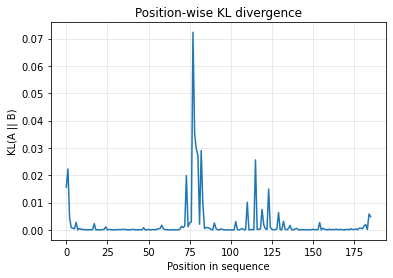

In [56]:
import matplotlib.pyplot as plt

plt.plot(kl_per_position)
plt.xlabel("Position in sequence")
plt.ylabel("KL(A || B)")
plt.title("Position-wise KL divergence")
plt.grid(True, alpha=0.3)
plt.show()

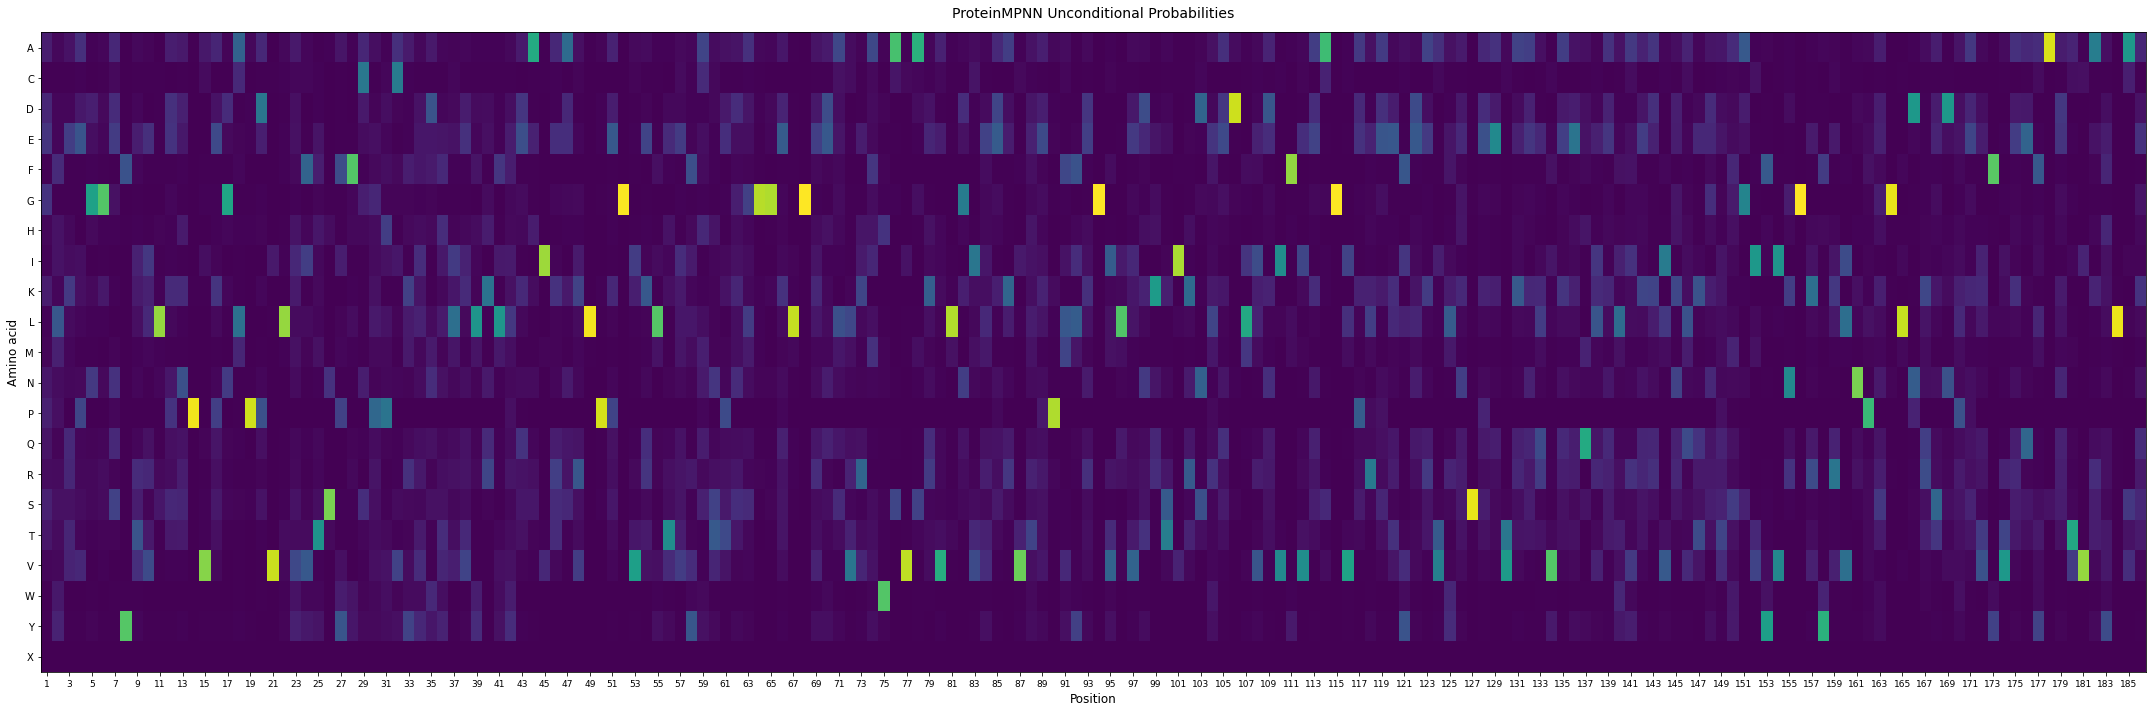

In [41]:
import matplotlib.pyplot as plt

# ─── Much taller figure ───
# width=40 keeps the long sequence readable
# height=30 → 35 → even 40+ gives generous vertical room for 21 rows
plt.figure(figsize=(30, 10))           # ← main change: much larger height

plt.imshow(probs_reordered.T, aspect='auto')     # 'auto' helps when height ≠ width a lot

plt.yticks(range(21), alphabet)

plt.xticks(
    ticks=range(0, 186, 2),
    labels=range(1, 187, 2),
    rotation=0,                        # 90 or 45 if labels start overlapping
    fontsize=9                         # optional: slightly smaller to fit more
)

plt.xlabel("Position", fontsize=12)
plt.ylabel("Amino acid", fontsize=12)

# Uncomment if you want the colorbar back (and make it taller-friendly)
# cbar = plt.colorbar(label="Probability", fraction=0.046, pad=0.04)
# cbar.ax.tick_params(labelsize=10)

plt.title("ProteinMPNN Unconditional Probabilities", fontsize=14, pad=15)

# Helps prevent label cutoff on tall/narrow layouts
plt.tight_layout()

plt.show()

In [57]:
p_num =  28
d = np.load(f"ProteinMPNN/outputs/1wcwA_insert_outputs/1wcwA_insert_permutation_28/conditional_probs_only/1wcwA_insert_permutation_28.npz")

d.files
# ['log_p', 'S', 'mask', 'design_mask']

log_p = d["log_p"]          # shape (1, L, 21)
probs = np.exp(log_p)       # convert from log-space
## Alphabet used by MPNN
alphabet = list("ACDEFGHIKLMNPQRSTVWYX")

probs_reordered = np.roll(probs, p_num, axis=1)

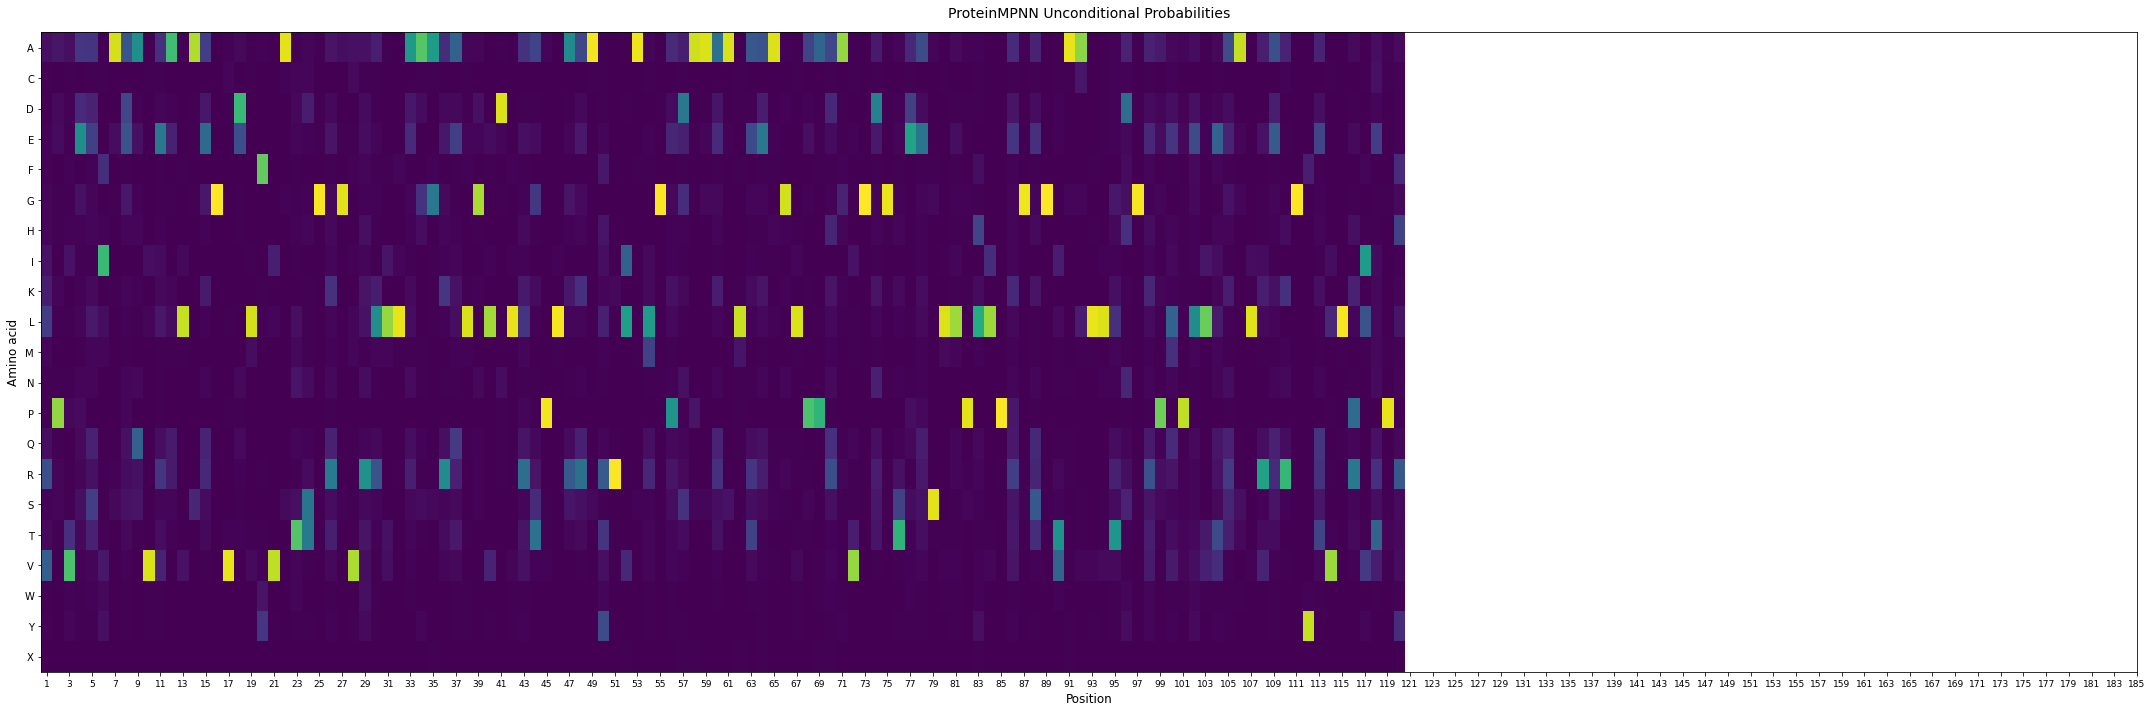

In [58]:
import matplotlib.pyplot as plt

# ─── Much taller figure ───
# width=40 keeps the long sequence readable
# height=30 → 35 → even 40+ gives generous vertical room for 21 rows
plt.figure(figsize=(30, 10))           # ← main change: much larger height

plt.imshow(probs_reordered.T, aspect='auto')     # 'auto' helps when height ≠ width a lot

plt.yticks(range(21), alphabet)

plt.xticks(
    ticks=range(0, 186, 2),
    labels=range(1, 187, 2),
    rotation=0,                        # 90 or 45 if labels start overlapping
    fontsize=9                         # optional: slightly smaller to fit more
)

plt.xlabel("Position", fontsize=12)
plt.ylabel("Amino acid", fontsize=12)

# Uncomment if you want the colorbar back (and make it taller-friendly)
# cbar = plt.colorbar(label="Probability", fraction=0.046, pad=0.04)
# cbar.ax.tick_params(labelsize=10)

plt.title("ProteinMPNN Unconditional Probabilities", fontsize=14, pad=15)

# Helps prevent label cutoff on tall/narrow layouts
plt.tight_layout()

plt.show()

In [ ]:
mean_kl = np.mean(kl_per_position)                        # overall average difference
mean_kl

In [ ]:
kl_per_position

In [ ]:
kl = np.mean(kl_div(A, B, axis=-1))
kl